# 02 — Visualizing the data

This notebook focuses on raw data and targets. Select one gas at the top and rerun all cells.
No derived features are created. A clearly marked single-point linear baseline is fitted only
at the end to make R² and error measures comparable.

## Software, controls, and plot settings

Change only `GAS` and `TRANSFORM`, then use **Run All** so every figure uses the same choice.
NumPy loads the arrays and calculates summaries; Matplotlib displays distributions, ECDFs,
scatter plots, signal bands, and temperature profiles. `dataset_pipeline` supplies the frozen
UGM splits and the 48 allowed phase-boundary points.

The final single-point line is only an orientation baseline. When reading the figures, inspect
curvature, outliers, changing density, and split differences instead of relying on one
correlation value.

In [1]:
# Only required choices:
GAS = "hydrogen"
TRANSFORM = "stored"  # alternative: "log1p"

# Allowed:
# acetic_acid, acetone, carbon_monoxide, ethanol, ethyl_acetate,
# formaldehyde, hydrogen, isopropanol, toluene, xylene

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))
from dataset_pipeline import *

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unknown gas: {GAS}")
if TRANSFORM not in TRANSFORMS:
    raise ValueError(f"Unknown transformation: {TRANSFORM}")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the prepared dataset

In [3]:
data_path = project_root() / "Data" / "seminar_point_datasets" /             f"all_raw_values__{TRANSFORM}__single_sensor.npz"
if not data_path.exists():
    export_base_datasets(data_path.parent, TRANSFORM)
archive = np.load(data_path)

target_names = (*GAS_TARGETS, "water", "VOCsum", "range")
splits = {}
for split in SPLIT_NAMES:
    splits[split] = {
        "X": archive[f"X_{split}"],
        "targets": {
            name: archive[f"target_{name}_{split}"]
            for name in target_names
        },
        "source_indices": archive[f"source_indices_{split}"],
        "source": "merged_official_train_and_test",
        "transform": TRANSFORM,
    }
archive.close()

for split in SPLIT_NAMES:
    X = splits[split]["X"]
    y = splits[split]["targets"][GAS]
    print(
        f"{split:>5}: X={X.shape}, {GAS}={y.min():.2f}-{y.max():.2f} ppb, "
        f"UGMs={len(np.unique(splits[split]['targets']['range']))}"
    )

train: X=(1090, 1, 1440), hydrogen=401.40-1997.20 ppb, UGMs=318
  val: X=(274, 1, 1440), hydrogen=407.28-1986.30 ppb, UGMs=80
 test: X=(338, 1, 1440), hydrogen=403.35-1975.20 ppb, UGMs=100
test_extra: X=(1392, 1, 1440), hydrogen=400.05-1999.20 ppb, UGMs=402


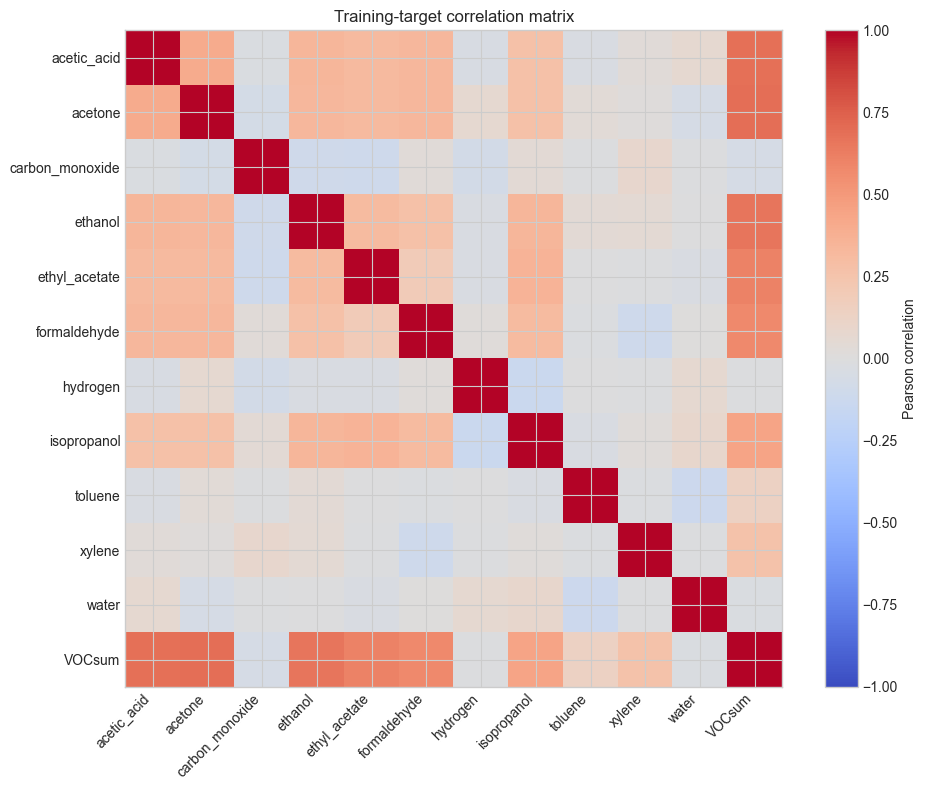

In [4]:
correlation_targets = list(GAS_TARGETS) + ["water", "VOCsum"]
target_matrix = np.column_stack([
    splits["train"]["targets"][name]
    for name in correlation_targets
])
target_correlation = np.corrcoef(target_matrix, rowvar=False)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(target_correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(
    range(len(correlation_targets)),
    correlation_targets,
    rotation=45,
    ha="right",
)
ax.set_yticks(range(len(correlation_targets)), correlation_targets)
ax.set_title("Training-target correlation matrix")
fig.colorbar(image, ax=ax, label="Pearson correlation")
fig.tight_layout()

## 2. Distribution of the selected target

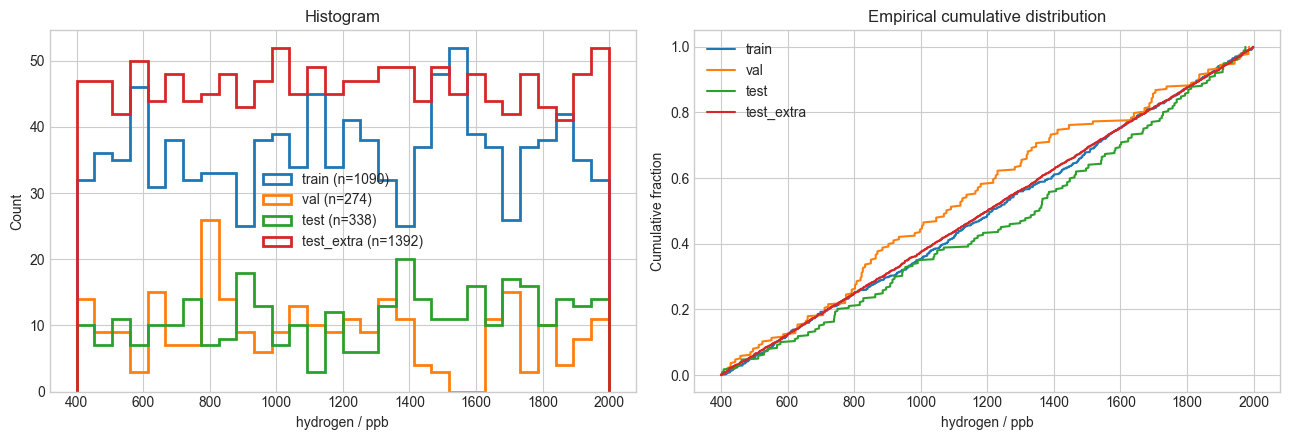

In [5]:
colors = {
    "train": "tab:blue", "val": "tab:orange",
    "test": "tab:green", "test_extra": "tab:red",
}
all_y = np.concatenate([
    splits[name]["targets"][GAS] for name in SPLIT_NAMES
])
bins = np.linspace(all_y.min(), all_y.max(), 31)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for split in SPLIT_NAMES:
    y = splits[split]["targets"][GAS]
    axes[0].hist(
        y, bins=bins, histtype="step", linewidth=2,
        label=f"{split} (n={len(y)})", color=colors[split]
    )
    sorted_y = np.sort(y)
    axes[1].plot(
        sorted_y, np.linspace(0, 1, len(sorted_y)),
        label=split, color=colors[split]
    )
axes[0].set(xlabel=f"{GAS} / ppb", ylabel="Count", title="Histogram")
axes[1].set(
    xlabel=f"{GAS} / ppb", ylabel="Cumulative fraction",
    title="Empirical cumulative distribution"
)
for ax in axes:
    ax.legend()
plt.tight_layout()

## 3. Target values across UGM IDs

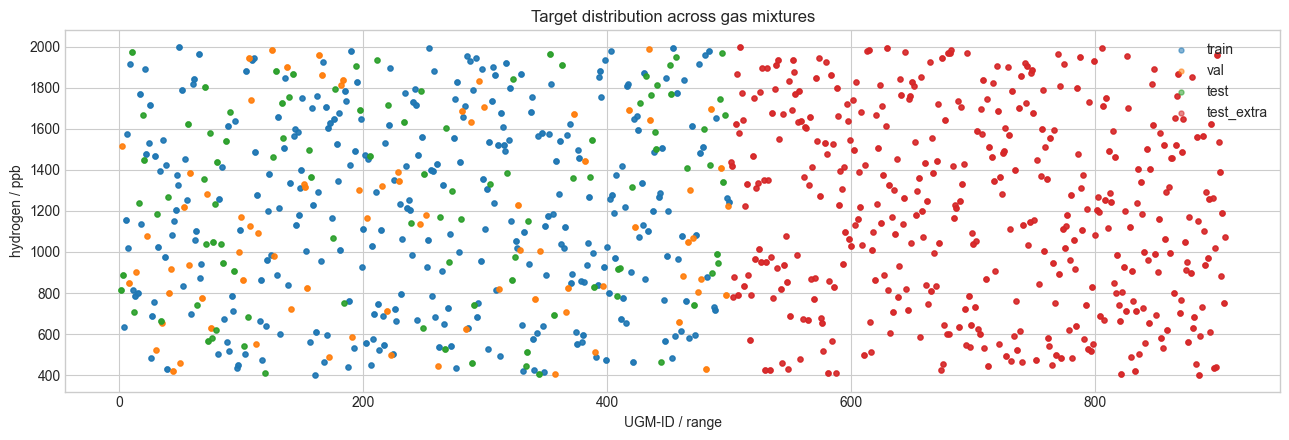

In [6]:
plt.figure(figsize=(13, 4.5))
for split in SPLIT_NAMES:
    plt.scatter(
        splits[split]["targets"]["range"],
        splits[split]["targets"][GAS],
        s=13, alpha=0.55, label=split, color=colors[split]
    )
plt.xlabel("UGM-ID / range")
plt.ylabel(f"{GAS} / ppb")
plt.title("Target distribution across gas mixtures")
plt.legend()
plt.tight_layout()

## 4. Full raw signal with variability bands

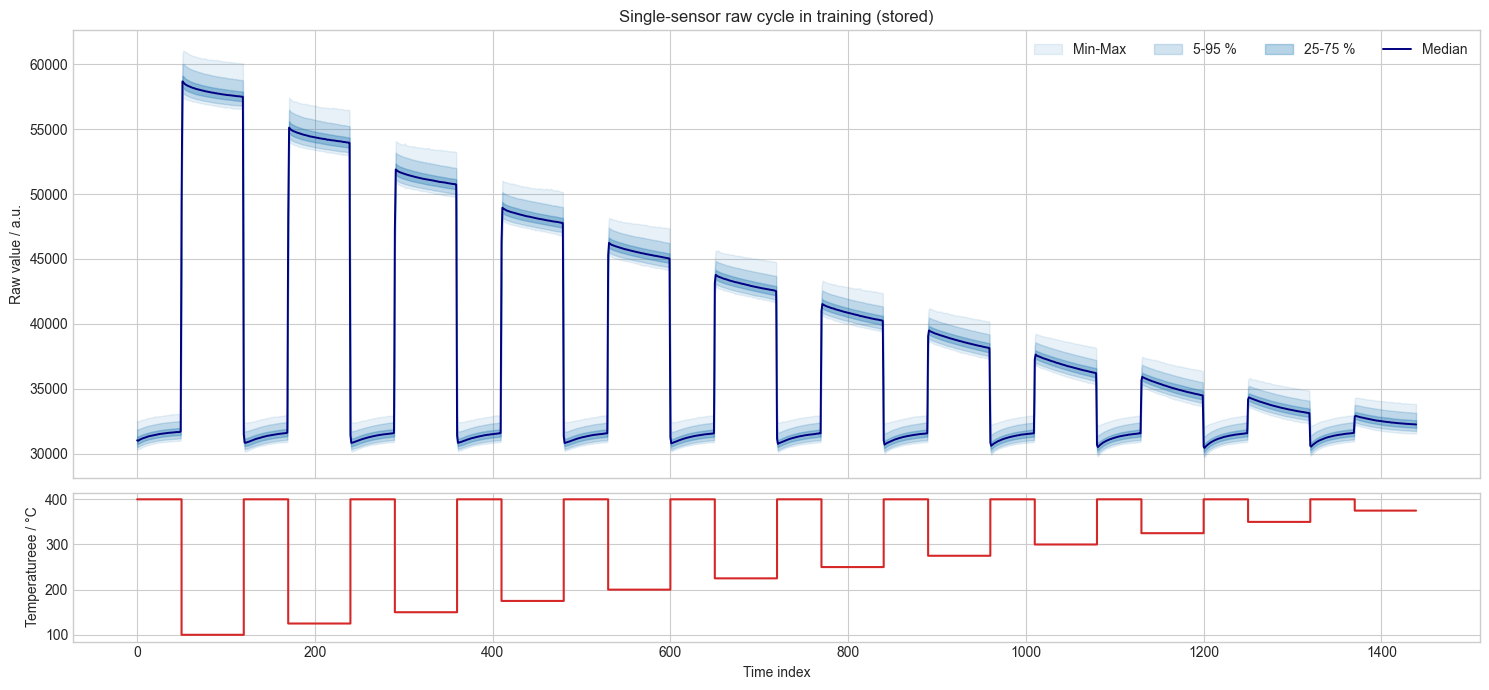

In [7]:
X_train = splits["train"]["X"][:, 0, :]
x_axis = np.arange(CYCLE_SAMPLES)
q05, q25, median, q75, q95 = np.quantile(
    X_train, [0.05, 0.25, 0.50, 0.75, 0.95], axis=0
)
minimum = X_train.min(axis=0)
maximum = X_train.max(axis=0)

fig, axes = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)
axes[0].fill_between(
    x_axis, minimum, maximum, color="tab:blue", alpha=0.10,
    label="Min-Max"
)
axes[0].fill_between(
    x_axis, q05, q95, color="tab:blue", alpha=0.20,
    label="5-95 %"
)
axes[0].fill_between(
    x_axis, q25, q75, color="tab:blue", alpha=0.32,
    label="25-75 %"
)
axes[0].plot(x_axis, median, color="navy", linewidth=1.4, label="Median")
axes[0].set(
    ylabel="Raw value / a.u.",
    title=f"Single-sensor raw cycle in training ({TRANSFORM})"
)
axes[0].legend(ncol=4)
axes[1].step(
    x_axis, temperature_profile(), where="post", color="tab:red"
)
axes[1].set(xlabel="Time index", ylabel="Temperatureee / °C")
plt.tight_layout()

The min–max band contains every observed extreme. Quantile bands are more robust and show
where most raw cycles actually lie.

## 5. Example cycles at low, medium, and high target levels

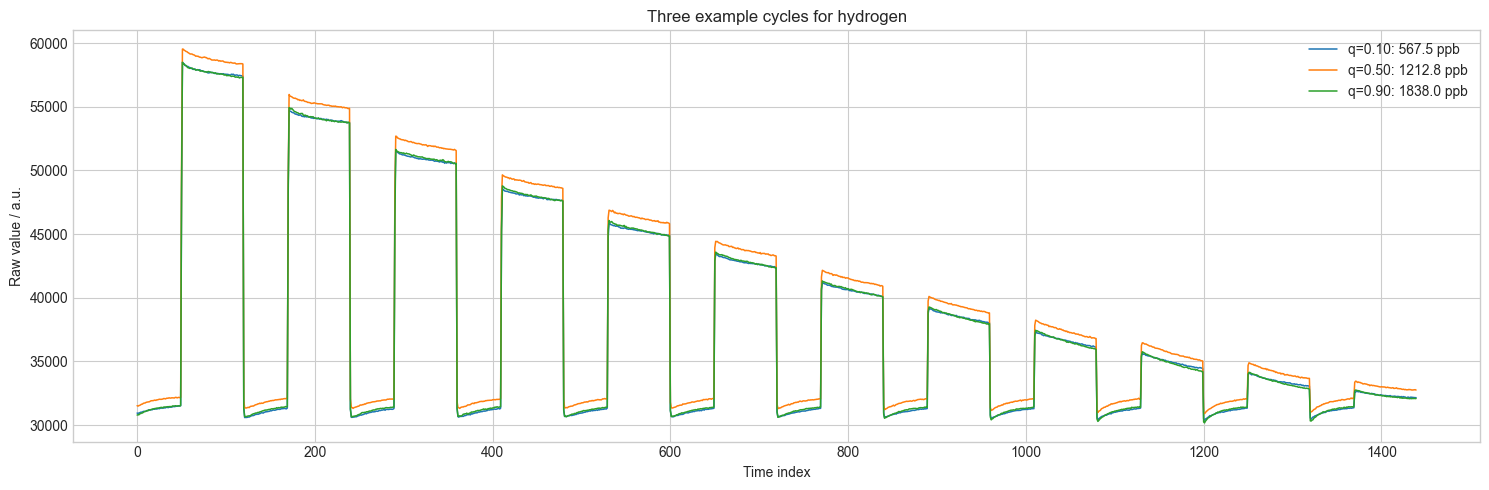

In [8]:
y_train = splits["train"]["targets"][GAS]
levels = (0.10, 0.50, 0.90)
fig, ax = plt.subplots(figsize=(15, 5))
for quantile in levels:
    wanted = np.quantile(y_train, quantile)
    index = int(np.argmin(np.abs(y_train - wanted)))
    ax.plot(
        X_train[index], linewidth=1.1,
        label=f"q={quantile:.2f}: {y_train[index]:.1f} ppb"
    )
ax.set(
    xlabel="Time index", ylabel="Raw value / a.u.",
    title=f"Three example cycles for {GAS}"
)
ax.legend()
plt.tight_layout()

## 6. Relationship between the selected gas and all 48 boundary points

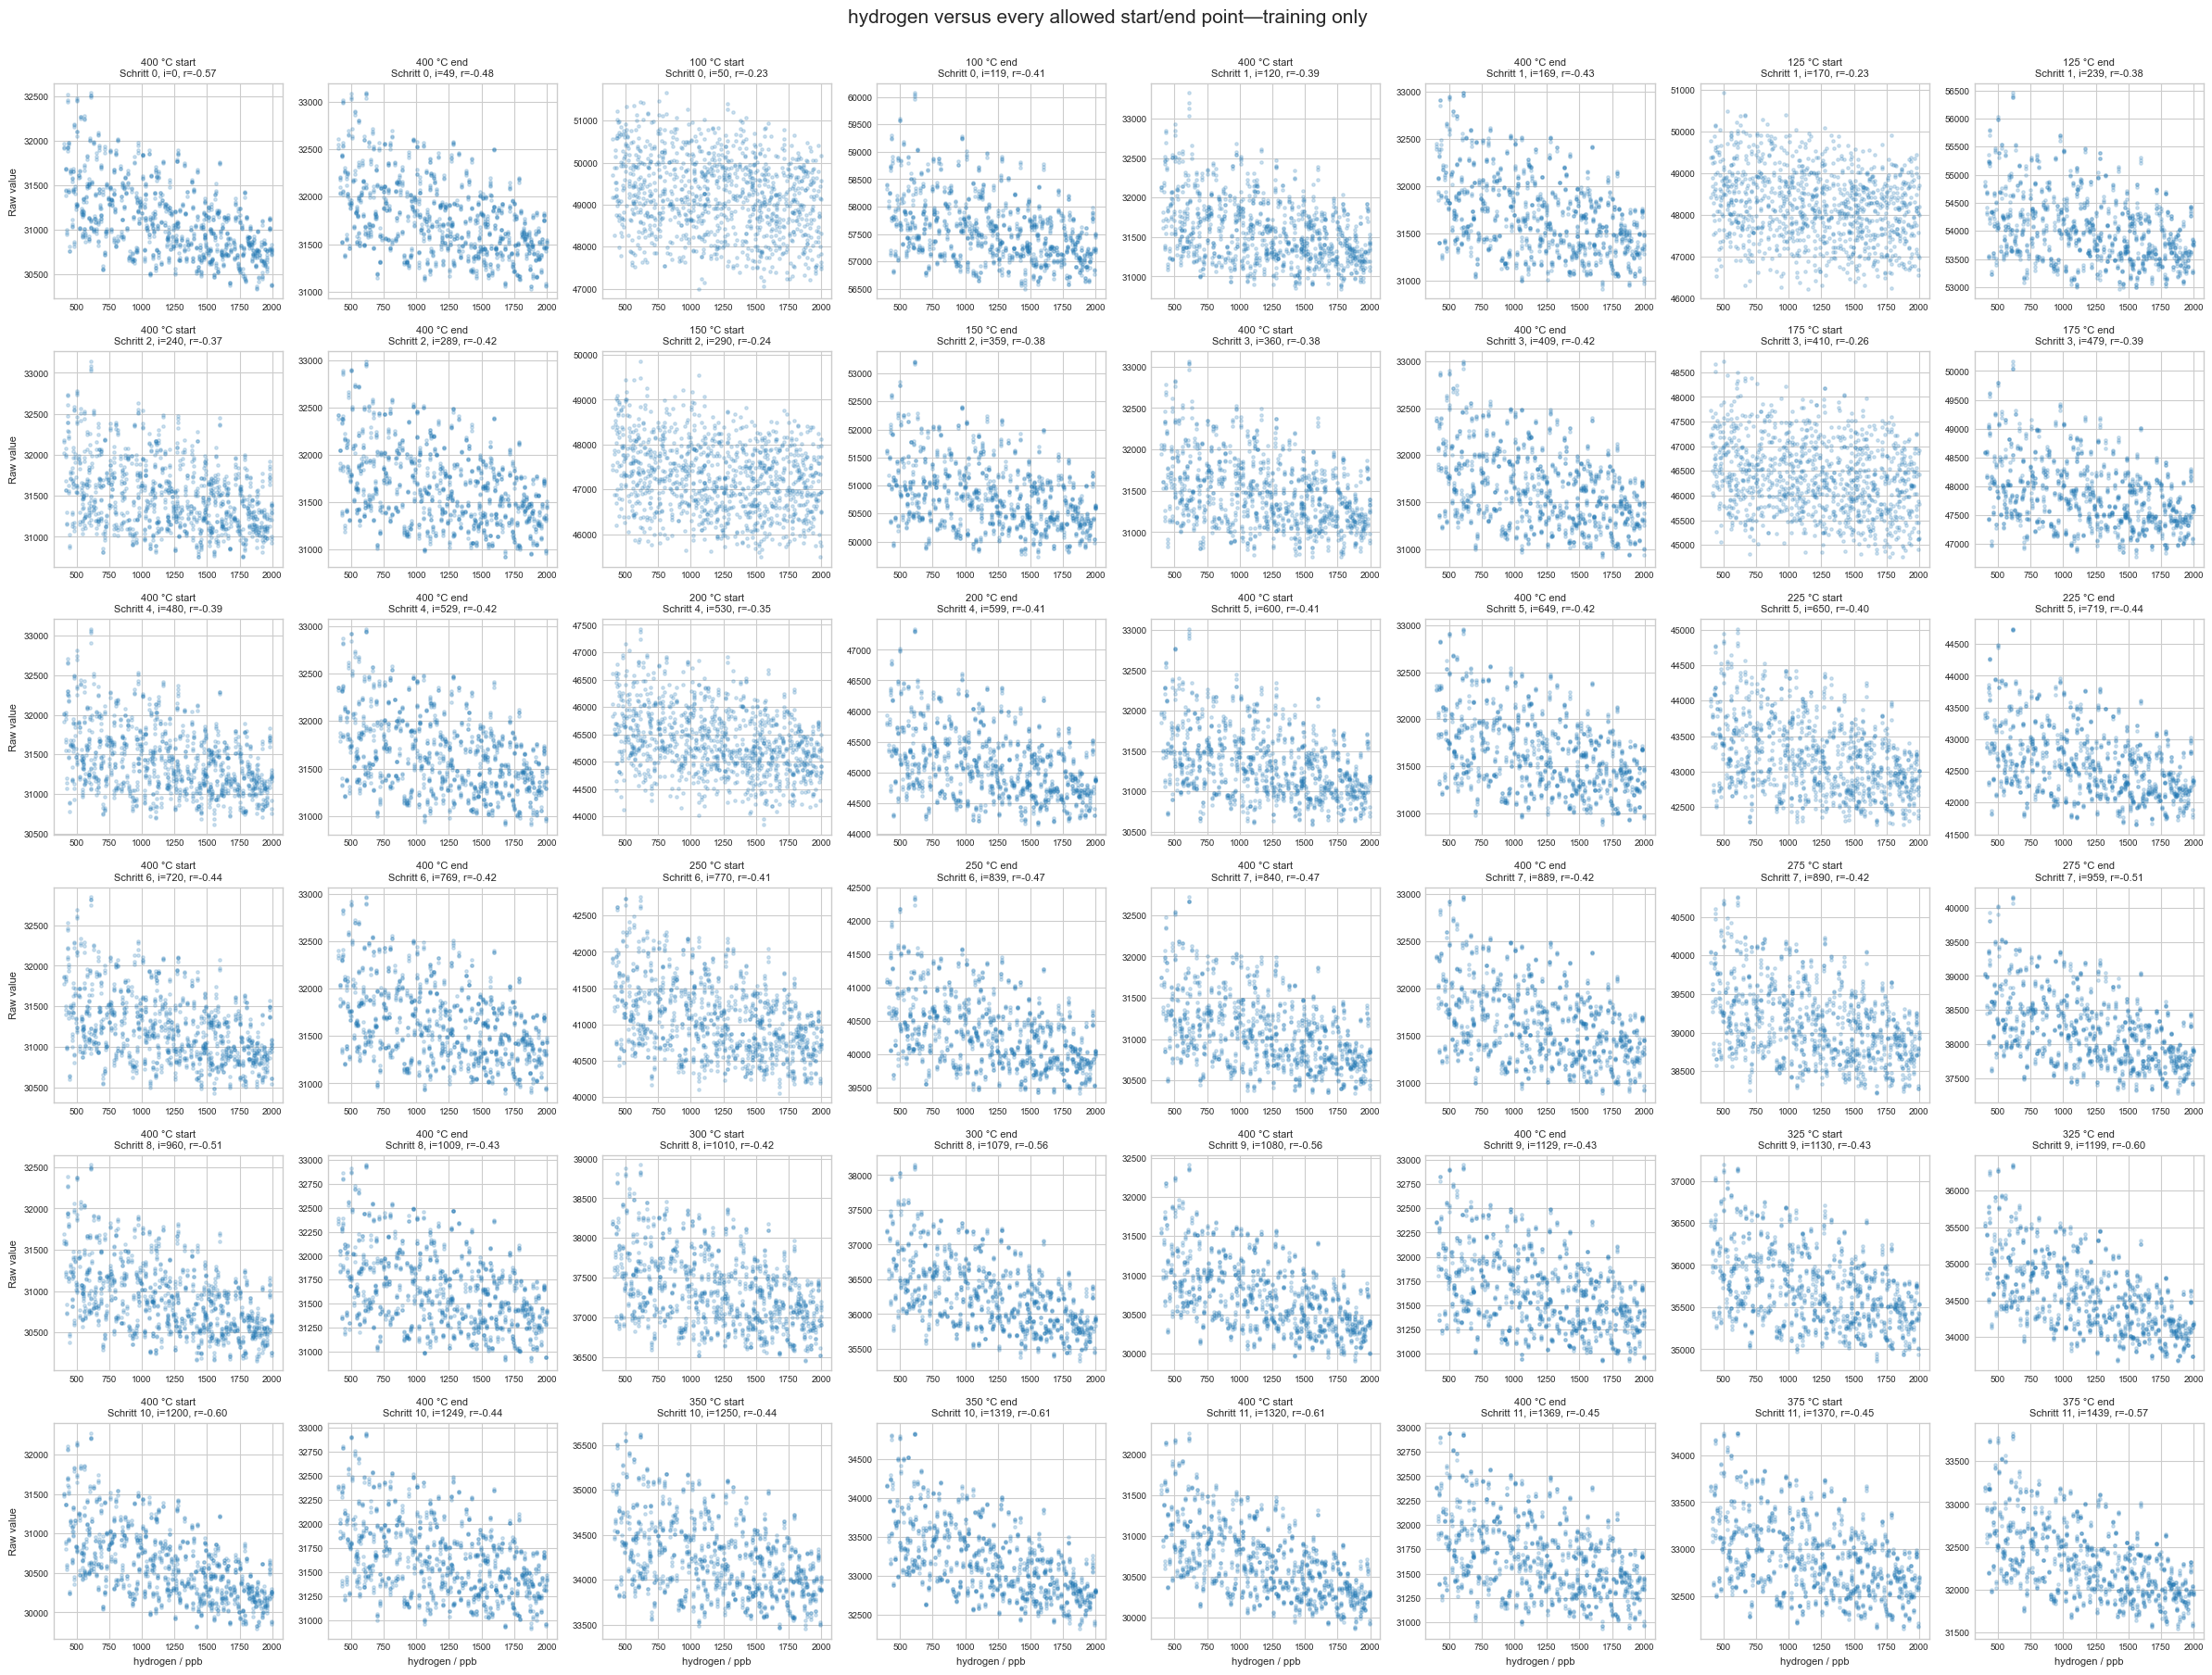

In [9]:
scores = score_boundary_points(splits, GAS)
fig, axes = plt.subplots(6, 8, figsize=(24, 18))
for ax, score in zip(axes.ravel(), scores):
    point_values = X_train[:, score.index]
    ax.scatter(
        y_train, point_values, s=6, alpha=0.20,
        color="tab:blue", rasterized=True
    )
    ax.set_title(
        f"{score.temperature_c} °C {score.edge}\n"
        f"Schritt {score.cycle_step}, i={score.index}, "
        f"r={score.target_correlation:+.2f}",
        fontsize=8
    )
    ax.tick_params(labelsize=7)
for ax in axes[-1]:
    ax.set_xlabel(f"{GAS} / ppb", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Raw value", fontsize=8)
fig.suptitle(
    f"{GAS} versus every allowed start/end point—training only",
    fontsize=15, y=1.002
)
plt.tight_layout()

## 7. Overview of correlations across the 48 points

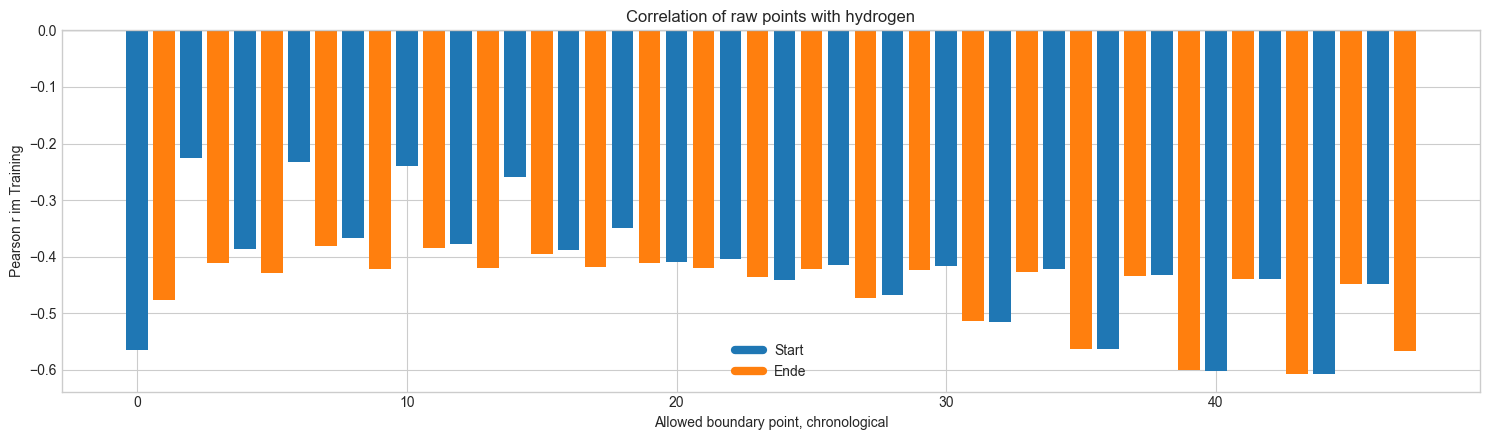

In [10]:
fig, ax = plt.subplots(figsize=(15, 4.5))
positions = np.arange(len(scores))
correlations = [score.target_correlation for score in scores]
point_colors = [
    "tab:blue" if score.edge == "start" else "tab:orange"
    for score in scores
]
ax.bar(positions, correlations, color=point_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    xlabel="Allowed boundary point, chronological",
    ylabel="Pearson r im Training",
    title=f"Correlation of raw points with {GAS}"
)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color="tab:blue", lw=6, label="Start"),
        plt.Line2D([0], [0], color="tab:orange", lw=6, label="Ende"),
    ]
)
plt.tight_layout()

## 8. Selected points shown separately by split

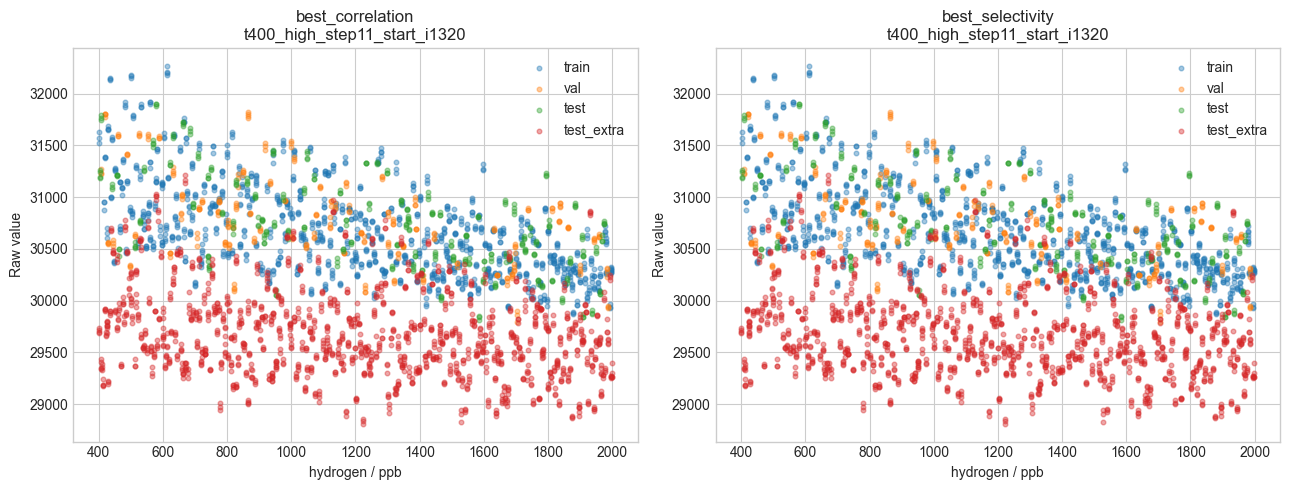

In [11]:
chosen = selected_point_scores(scores)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, selection in zip(
    axes, ("best_correlation", "best_selectivity")
):
    score = chosen[selection]
    for split in SPLIT_NAMES:
        ax.scatter(
            splits[split]["targets"][GAS],
            splits[split]["X"][:, 0, score.index],
            s=11, alpha=0.40, color=colors[split], label=split
        )
    ax.set(
        xlabel=f"{GAS} / ppb", ylabel="Raw value",
        title=f"{selection}\n{score.point_id}"
    )
    ax.legend()
plt.tight_layout()

Both points were selected using training data only. Validation and test rows are displayed
after selection solely to reveal distribution shifts and generalization.

## 9. R², MSE, RMSE, and MAE for every individual point

Error metrics require predictions. For each boundary point, fit `target = a × raw + b`
on training data only, then apply the unchanged line to validation, test, and `test_extra`.

In [12]:
def prediction_metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - float(np.sum(residual ** 2)) / denominator
    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": float(np.mean(np.abs(residual))),
    }


point_evaluations = []
for score in scores:
    x_train = splits["train"]["X"][:, 0, score.index].astype(float)
    y_fit = splits["train"]["targets"][GAS].astype(float)
    design = np.column_stack([x_train, np.ones(len(x_train))])
    slope, intercept = np.linalg.lstsq(
        design, y_fit, rcond=None
    )[0]

    metrics = {}
    for split in SPLIT_NAMES:
        x = splits[split]["X"][:, 0, score.index].astype(float)
        y = splits[split]["targets"][GAS].astype(float)
        prediction = slope * x + intercept
        metrics[split] = prediction_metrics(y, prediction)

    point_evaluations.append({
        "score": score,
        "slope": float(slope),
        "intercept": float(intercept),
        "metrics": metrics,
    })

ranked = sorted(
    point_evaluations,
    key=lambda item: item["metrics"]["val"]["RMSE"],
)
print("The 12 points with the lowest validation RMSE")
print(
    "Point                                "
    "R2 train   R2 val  R2 test R2 extra | "
    "RMSE train RMSE val RMSE test RMSE extra"
)
for item in ranked[:12]:
    score = item["score"]
    m = item["metrics"]
    print(
        f"{score.point_id:36s} "
        f"{m['train']['R2']:8.3f} {m['val']['R2']:8.3f} "
        f"{m['test']['R2']:8.3f} {m['test_extra']['R2']:8.3f} | "
        f"{m['train']['RMSE']:10.3f} {m['val']['RMSE']:8.3f} "
        f"{m['test']['RMSE']:9.3f} "
        f"{m['test_extra']['RMSE']:10.3f}"
    )

The 12 points with the lowest validation RMSE
Point                                R2 train   R2 val  R2 test R2 extra | RMSE train RMSE val RMSE test RMSE extra
t350_low_step10_end_i1319               0.368    0.254    0.322   -1.881 |    364.019  393.032   382.013    782.963
t400_high_step11_start_i1320            0.370    0.248    0.318   -1.900 |    363.711  394.531   383.094    785.545
t325_low_step09_end_i1199               0.361    0.240    0.315   -2.079 |    366.270  396.556   384.043    809.439
t400_high_step10_start_i1200            0.363    0.239    0.315   -2.126 |    365.697  396.794   384.046    815.596
t375_low_step11_end_i1439               0.321    0.202    0.265   -1.805 |    377.440  406.307   397.847    772.532
t400_high_step00_start_i0000            0.320    0.195    0.255   -1.726 |    377.774  408.050   400.414    761.589
t400_high_step09_start_i1080            0.317    0.183    0.264   -2.097 |    378.519  411.287   398.000    811.758
t300_low_step08_end_i1079 

## 10. All four metrics across the 48 points

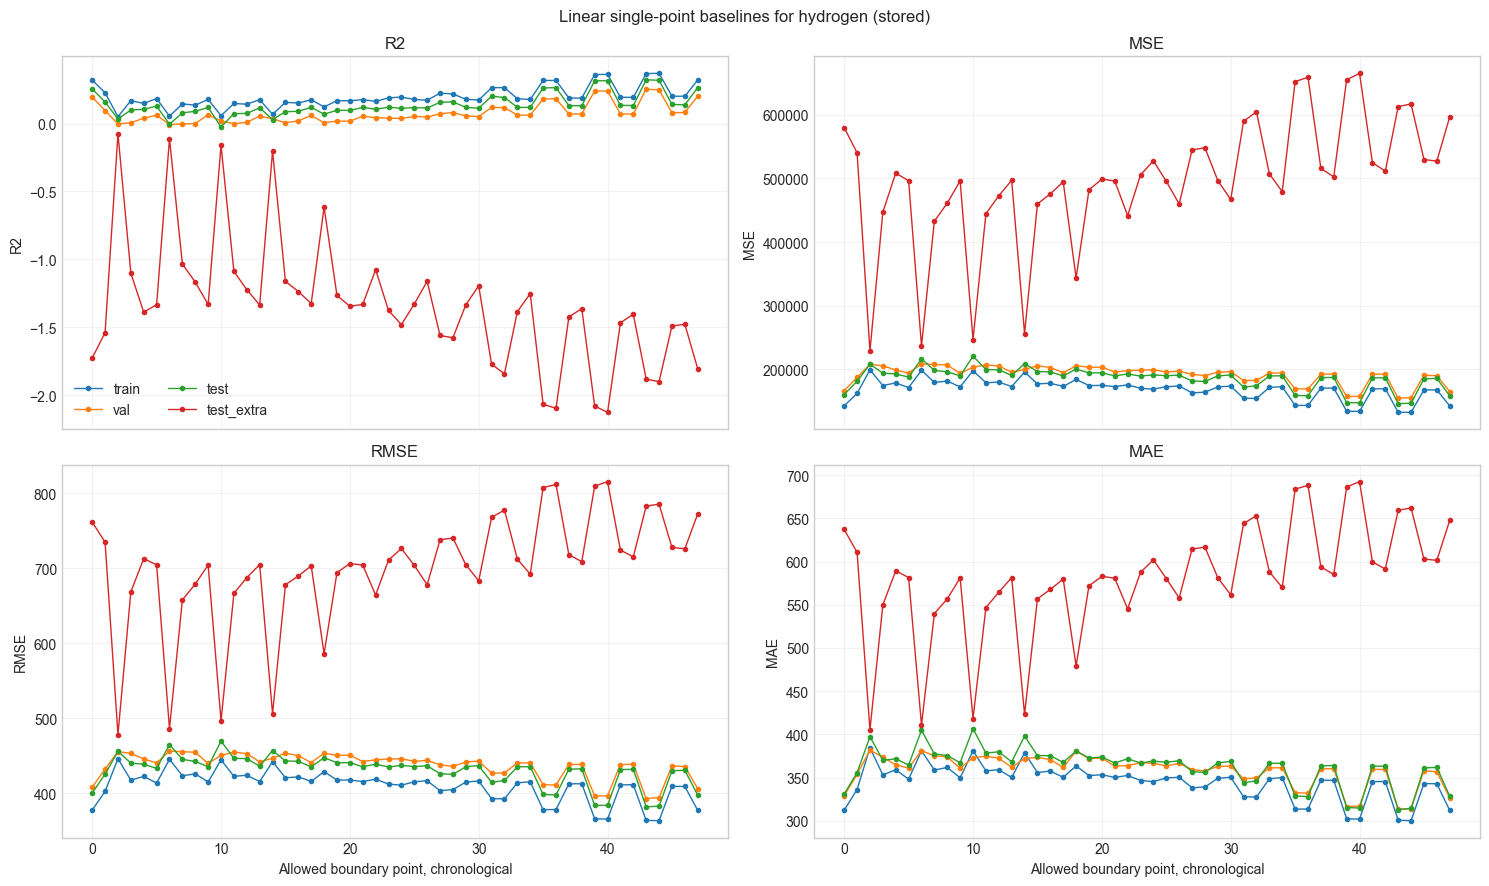

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for ax, metric in zip(axes.ravel(), ("R2", "MSE", "RMSE", "MAE")):
    for split in SPLIT_NAMES:
        values = [
            item["metrics"][split][metric]
            for item in point_evaluations
        ]
        ax.plot(
            np.arange(len(values)), values, marker=".", linewidth=1,
            label=split, color=colors[split]
        )
    ax.set(title=metric, ylabel=metric)
    ax.grid(alpha=0.25)
for ax in axes[-1]:
    ax.set_xlabel("Allowed boundary point, chronological")
axes[0, 0].legend(ncol=2)
fig.suptitle(
    f"Linear single-point baselines for {GAS} ({TRANSFORM})"
)
plt.tight_layout()

## 11. Complete metrics for the two previously selected points

In [14]:
by_index = {
    item["score"].index: item for item in point_evaluations
}
for selection in ("best_correlation", "best_selectivity"):
    score = chosen[selection]
    item = by_index[score.index]
    print(
        f"\n{selection}: {score.point_id}\n"
        f"Line: {GAS} = {item['slope']:.8g} * Raw value "
        f"+ {item['intercept']:.8g}"
    )
    print("Split          R2           MSE          RMSE           MAE")
    for split in SPLIT_NAMES:
        m = item["metrics"][split]
        print(
            f"{split:10s} {m['R2']:11.4f} {m['MSE']:13.4f} "
            f"{m['RMSE']:13.4f} {m['MAE']:13.4f}"
        )


best_correlation: t400_high_step11_start_i1320
Line: hydrogen = -0.6329687 * Raw value + 20622.708
Split          R2           MSE          RMSE           MAE
train           0.3695   132285.6649      363.7110      300.0910
val             0.2478   155654.7803      394.5311      314.0348
test            0.3184   146761.1192      383.0941      314.2240
test_extra     -1.9002   617080.1695      785.5445      662.0564

best_selectivity: t400_high_step11_start_i1320
Line: hydrogen = -0.6329687 * Raw value + 20622.708
Split          R2           MSE          RMSE           MAE
train           0.3695   132285.6649      363.7110      300.0910
val             0.2478   155654.7803      394.5311      314.0348
test            0.3184   146761.1192      383.0941      314.2240
test_extra     -1.9002   617080.1695      785.5445      662.0564


For training data, simple linear regression with an intercept gives R² = r². This identity
does not generally hold outside training; `test_extra` can be much worse or even negative because
its concentration range is extended.